<div align="center">
    
## <font color = #4854E8>**Temporal Dynamics of Urban Air Quality: A Two-Phase Clustering and Drift Analysis**</font>
<div>

**Dataset Overview:**

The dataset contains 9,358 hourly recordings collected from a multisensor device positioned at ground level in an urban area in Italy (March 2004–March 2005). It includes readings from five metal-oxide chemical sensors, reference concentrations for pollutants (such as CO, NOx, benzene, etc.), along with environmental factors like temperature, humidity, and absolute humidity. 

**Project Overview:**

In modern urban environments, monitoring air quality is not only a scientific concern but also a critical public health priority. Sensors used to measure pollutants operate within dynamic conditions influenced by changing environmental and human factors. This project analyses a year’s worth of air quality data from an Italian city to understand how pollution patterns evolve from the warmer summer months to the colder winter season. A key challenge addressed in this study is model drift, where a machine learning model trained on one seasonal pattern may become less accurate when applied to another due to changes in traffic behaviour, heating demands, and atmospheric conditions. 

The objective of this work is to follow a complete data science pipeline, starting from raw sensor data and progressing through preprocessing, transformation, clustering, and evaluation, to ultimately analyse how environmental patterns shift over time. This includes exploratory data analysis to understand pollutant relationships, data cleaning to ensure reliability, feature scaling for consistency, and the application of K-Means clustering to identify three distinct air quality states: low, moderate, and high pollution. The clustering results are evaluated using metrics such as the Silhouette Score, followed by drift analysis to quantify seasonal changes. Finally, PCA-based visualisation is used to represent these shifts in a reduced feature space, enabling clearer interpretation and supporting the development of practical insights for urban air quality monitoring and management.

### <font color = #41EA46> **1: Import Libraries**</font>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import RobustScaler

from sklearn.cluster import KMeans

from plotnine import *
import plotnine

from scipy.stats import entropy

from sklearn.decomposition import PCA

from scipy.spatial.distance import cdist

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

import warnings
warnings.filterwarnings("ignore")

### <font color = #41EA46> **2: Load dataset**<font>

In [2]:
df = pd.read_excel("AirQualityUCI.xlsx")

print("\n===== BASIC INFO =====")
print("Shape:", df.shape)        
print("Columns:", df.columns)  


===== BASIC INFO =====
Shape: (9357, 15)
Columns: Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')


### <font color = #41EA46> **3: Data Cleaning**<font>

In [3]:
# Check for duplicates
print("\n===== DUPLICATES =====")
print("Duplicate rows:", df.duplicated().sum())


===== DUPLICATES =====
Duplicate rows: 0


In [4]:
# Create a proper Datetime index
df['Datetime'] = df['Date'] + pd.to_timedelta(df['Time'].astype(str).str.replace('.', ':'), errors='coerce')
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

####  <font color = blue> **Handling Missing Values** </font>

The dataset uses -200 to denote missing values. So, It is required to convert -200 into proper missing values NaN.

In [5]:
# Replace -200 with NaN
df.replace(-200, np.nan, inplace=True)

In [6]:
print("\n===== MISSING VALUES =====")
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
"Missing Count": missing,
"Missing %": missing_percent
})
print(missing_table[missing_table["Missing Count"] > 0])


===== MISSING VALUES =====
               Missing Count  Missing %
NMHC(GT)                8443  90.231912
CO(GT)                  1683  17.986534
NO2(GT)                 1642  17.548360
NOx(GT)                 1639  17.516298
PT08.S1(CO)              366   3.911510
C6H6(GT)                 366   3.911510
PT08.S2(NMHC)            366   3.911510
PT08.S3(NOx)             366   3.911510
PT08.S4(NO2)             366   3.911510
PT08.S5(O3)              366   3.911510
T                        366   3.911510
RH                       366   3.911510
AH                       366   3.911510


> - **NMHC(GT)** (Non-Metanic Hydrocarbon concentration) is missing over 90% of its data, making it statistically unsalvageable. So, it is required to **drop the NMHC(GT)** column entirely.
> - The sensor responses **PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2), PT08.S5(O3), T, RH, and AH** all have exactly 366 missing values. Since this is a time series and air quality doesn't change instantly, **Linear Interpolation** will be ustilized to deal with these particular missing values.
> - **C6H6(GT), CO(GT), NO2(GT), and NOx(GT)** are Ground Truth (GT) reference analyzer values from a certified station. Apart from C6H6, all the other gases have about 18% missing values. The best approach is to use **Linear Interpolation** for C6H6(GT) due to the time-dependent continuity. Then use **MICE (Multivariate Imputation)** for the remaining gases, allowing the model to leverage near-complete sensor readings to predict the missing values.

In [7]:
# Drop NMHC(GT) column entirely 
df.drop(columns=['NMHC(GT)'], inplace=True)

# Interpolate sensor responses & C6H6 values (the 3.9% group)
lin_impute_cols  = ['T', 'RH', 'AH', 'C6H6(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 
                 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
df[lin_impute_cols] = df[lin_impute_cols].interpolate(method='linear')

# Use Iterative Imputer for the GT gas missing values
datetime_index = df.index
num_cols = df.select_dtypes(include=[np.number]).columns
imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_data = imputer.fit_transform(df[num_cols])
df_cleaned = pd.DataFrame(imputed_data, columns=num_cols, index=datetime_index)

# Final Check
print(df_cleaned.isnull().sum())

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


### <font color = #41EA46> **4: Exploratory Data Analysis (EDA)**<font>

In [8]:
print("\n===== BASIC INFO =====")
df_cleaned.info()

print("\n===== SUMMARY STATISTICS =====")
df_cleaned.describe()


===== BASIC INFO =====
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float64
 1   PT08.S1(CO)    9357 non-null   float64
 2   C6H6(GT)       9357 non-null   float64
 3   PT08.S2(NMHC)  9357 non-null   float64
 4   NOx(GT)        9357 non-null   float64
 5   PT08.S3(NOx)   9357 non-null   float64
 6   NO2(GT)        9357 non-null   float64
 7   PT08.S4(NO2)   9357 non-null   float64
 8   PT08.S5(O3)    9357 non-null   float64
 9   T              9357 non-null   float64
 10  RH             9357 non-null   float64
 11  AH             9357 non-null   float64
dtypes: float64(12)
memory usage: 950.3 KB

===== SUMMARY STATISTICS =====


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.102113,1102.932925,10.178838,942.019562,237.395223,832.634930,109.528855,1453.172887,1032.422456,18.231754,49.189157,1.019621
std,1.442446,218.201561,7.503295,267.864854,209.906615,255.708807,47.427632,343.201361,404.442611,8.782368,17.194081,0.402203
min,0.071850,647.250000,0.149048,383.250000,-111.882720,322.000000,-10.447865,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,1.000000,937.500000,4.477145,736.000000,93.000000,654.000000,74.000000,1227.000000,733.250000,11.725000,35.800000,0.732280
50%,1.712579,1066.750000,8.289085,910.333333,174.300000,803.500000,106.000000,1459.500000,970.000000,17.575000,49.650000,0.989504
75%,2.800000,1238.750000,14.096486,1119.000000,316.000000,967.500000,137.500000,1668.250000,1293.000000,24.275001,62.250002,1.306671
max,11.900000,2039.750000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036


####  <font color = blue> **1: Correlation Heatmap** </font>

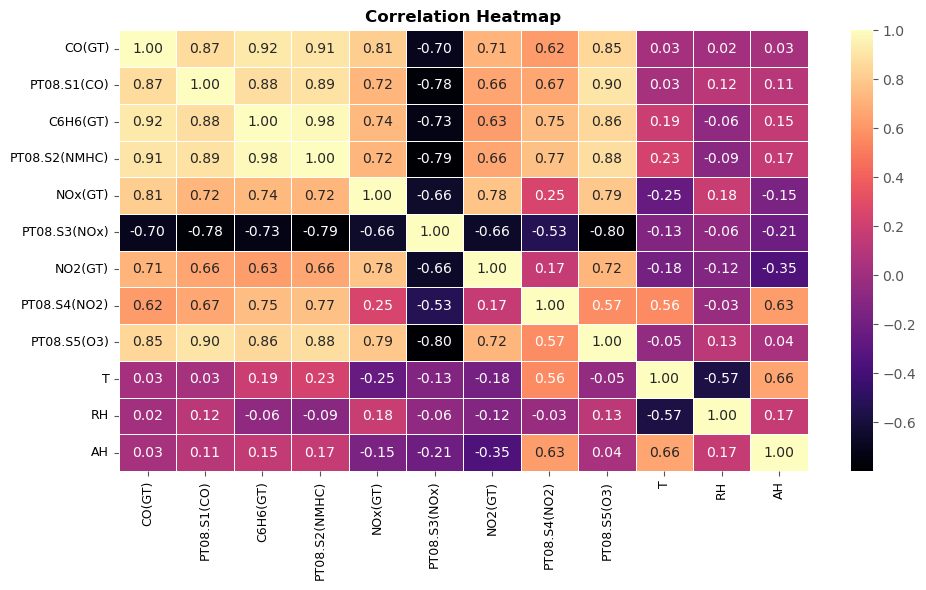

In [9]:
def correlation_heatmap(df_cleaned):
  
    plt.figure(figsize=(10, 6))
    corr = df_cleaned.corr()
    heatmap = sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f",  linewidths=0.5 )
    for text in heatmap.texts:
        text.set_fontsize(10)
        
    plt.title('Correlation Heatmap', fontsize=12, fontweight='bold', color='black')
    plt.xticks(fontsize=9, color='black')
    plt.yticks(fontsize=9, color='black')
    plt.gca().set_facecolor('#F5F5F5')
    plt.gca().spines['bottom'].set_color('black')
    plt.gca().spines['left'].set_color('black')
    
    plt.tight_layout()
    plt.show()

correlation_heatmap(df_cleaned);

> Interpretation:
> 
> - CO(GT) ↔ C6H6(GT) → 0.92
> - CO(GT) ↔ NOx(GT) → 0.81
> - NOx(GT) ↔ NO₂(GT) → 0.78
>
> **Strong positive correlations are observed among the reference gases, confirming a common emission source of traffic combustion.**
> 
> - PT08.S1(CO) ↔ CO(GT) → 0.86
> - PT08.S1(CO) ↔ C6H6(GT) → 0.88
> - PT08.S1(CO) ↔ PT08.S5 (O₃) → 0.90
>
> **The CO sensor tracks CO well but also responds strongly to other traffic-related gases. This indicates cross-sensitivity, and it does not represent a purely CO-specific signal.**
>
> - PT08.S3(NOx) ↔ NOx(GT) → −0.66
>
> **The strong negative correlation suggests that PT08.S3 NOx sensor response is inverted. The sensor is still usable but requires careful handling of the sign.**
> 
> - PT08.S4(NO₂) ↔ NO₂(GT) → 0.14
> - PT08.S4(NO₂) ↔ AH → 0.63
> - PT08.S4(NO₂) ↔ T → 0.56
>
> **PT08.S4 (NO₂ Sensor) is more strongly influenced by temperature and humidity environmental conditions. This indicates significant environmental bias, and it is unreliable for direct NO₂ prediction.**
>
> **Environmental Variables**
> 
> - T ↔ AH → 0.66 (expected physical relationship)
> - T ↔ NO₂(GT) → -0.18
> - T ↔ NOx(GT) → −0.27
>
> **Temperature (T): Higher temperatures are associated with lower NOx and NO₂ concentrations, likely due to atmospheric dispersion.**
>
> - AH ↔ NOx(GT) → -0.15
> - AH ↔ NO₂(GT) → −0.35
>
> **Absolute Humidity (AH): Atmospheric moisture content affects both pollutant chemistry and sensor response.**
>
> **Relative Humidity (RH): Shows mostly weak correlations and appears less influential in this dataset.**
>
> **PT08.S2(NMHC) and PT08.S5(O₃) exhibit strong correlations with multiple ground truth gases, indicating the cross-sensitivity between multiple gases and shared emission source effects.**
>
> **The correlation matrix reveals significant multicollinearity among traffic-related gases and sensor responses, with majority of correlations exceeding 0.8**.
---

####  <font color = blue> **2: Sensor vs. Reference Linearity** </font>

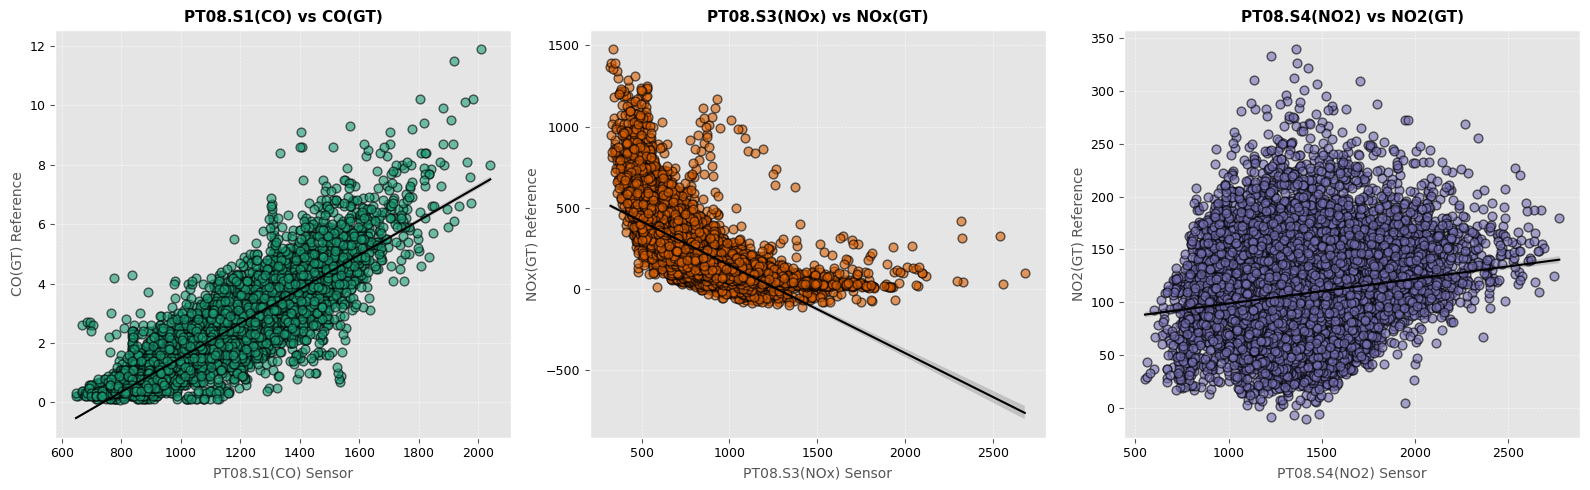

In [10]:
def plot_sensor_vs_reference(df_cleaned):
    
    plt.figure(figsize=(16,5))
    palette = sns.color_palette("Dark2")

    # CO sensor vs CO(GT)
    plt.subplot(1,3,1)
    sns.regplot(x='PT08.S1(CO)', y='CO(GT)', data=df_cleaned,
        scatter_kws={'s': 40, 'color': palette[0], 'alpha': 0.6, 'edgecolor': 'black'}, line_kws={'color': 'black', 'linewidth': 1.5})
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(fontsize=9, color='black')    
    plt.yticks(fontsize=9, color='black')
    plt.title('PT08.S1(CO) vs CO(GT)', fontweight='bold', fontsize=11)
    plt.xlabel('PT08.S1(CO) Sensor', fontsize=10)
    plt.ylabel('CO(GT) Reference', fontsize=10)

    # NOx sensor vs NOx(GT)
    plt.subplot(1,3,2)
    sns.regplot(x='PT08.S3(NOx)', y='NOx(GT)', data=df_cleaned,
        scatter_kws={'s': 40, 'color': palette[1], 'alpha': 0.6, 'edgecolor': 'black'}, line_kws={'color': 'black', 'linewidth': 1.5})
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(fontsize=9, color='black')    
    plt.yticks(fontsize=9, color='black')
    plt.title('PT08.S3(NOx) vs NOx(GT)', fontweight='bold', fontsize=11)
    plt.xlabel('PT08.S3(NOx) Sensor', fontsize=10)
    plt.ylabel('NOx(GT) Reference', fontsize=10)

    # NO2 sensor vs NO2(GT)
    plt.subplot(1,3,3)
    sns.regplot(x='PT08.S4(NO2)', y='NO2(GT)', data=df_cleaned,
        scatter_kws={'s': 40, 'color': palette[2], 'alpha': 0.6, 'edgecolor': 'black'}, line_kws={'color': 'black', 'linewidth': 1.5})
    
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(fontsize=9, color='black')    
    plt.yticks(fontsize=9, color='black')
    plt.title('PT08.S4(NO2) vs NO2(GT)', fontweight='bold', fontsize=11)
    plt.xlabel('PT08.S4(NO2) Sensor', fontsize=10)
    plt.ylabel('NO2(GT) Reference', fontsize=10)

    plt.tight_layout()
    plt.show()
    
plot_sensor_vs_reference(df_cleaned);

> Interpretation:
> - PT08.S1(CO) vs CO(GT) → Strong positive correlation
> - PT08.S3(NOx) vs NOx(GT) → Moderate negative correlation
> - PT08.S4(NO2) vs NO2(GT) → Very weak correlation
>
> **The above charts highlight that CO sensor readings can be used confidently, while NOx and NO2 sensors may require calibration or alternative modeling approaches.**
---

####  <font color = blue> **3: Environmental Influence on Sensors** </font>


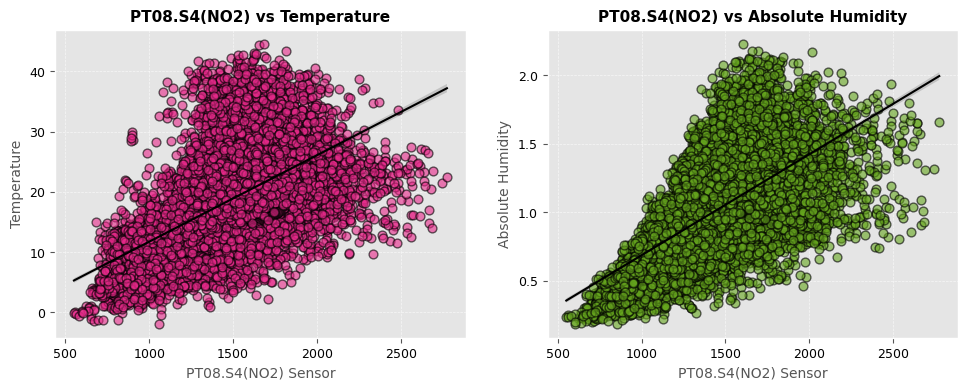

In [11]:
def sensor_s4_env_relationship(df_cleaned):
    
    plt.figure(figsize=(18,4))
    palette = sns.color_palette("Dark2")

    # PT08.S4(NO2) sensor vs Temperature
    plt.subplot(1,3,1)
    sns.regplot(x='PT08.S4(NO2)', y='T', data=df_cleaned,
        scatter_kws={'s': 40, 'color': palette[3], 'alpha': 0.6, 'edgecolor': 'black'}, line_kws={'color': 'black', 'linewidth': 1.5})
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(fontsize=9, color='black')    
    plt.yticks(fontsize=9, color='black')
    plt.title('PT08.S4(NO2) vs Temperature', fontweight='bold', fontsize=11)
    plt.xlabel('PT08.S4(NO2) Sensor', fontsize=10)
    plt.ylabel('Temperature', fontsize=10)

    # PT08.S4(NO2)sensor vs Absolute Humidity
    plt.subplot(1,3,2)
    sns.regplot(
        x='PT08.S4(NO2)', y='AH', data=df_cleaned,
        scatter_kws={'s': 40, 'color': palette[4], 'alpha': 0.6, 'edgecolor': 'black'}, line_kws={'color': 'black', 'linewidth': 1.5})
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(fontsize=9, color='black')    
    plt.yticks(fontsize=9, color='black')
    plt.title('PT08.S4(NO2) vs Absolute Humidity', fontweight='bold', fontsize=11)
    plt.xlabel('PT08.S4(NO2) Sensor', fontsize=10)
    plt.ylabel('Absolute Humidity', fontsize=10)
    
sensor_s4_env_relationship(df_cleaned);

> Interpretation:
>
> **The above scatter plots show a clear positive relationship between PT08.S4(NO₂) sensor response and both temperature and absolute humidity. This confirms that environmental conditions significantly influence the sensor output, indicating environmental bias and reduced specificity to NO₂ concentration.**
---

####  <font color = blue> **4: Hourly and Weekly Pollution Patterns** </font>

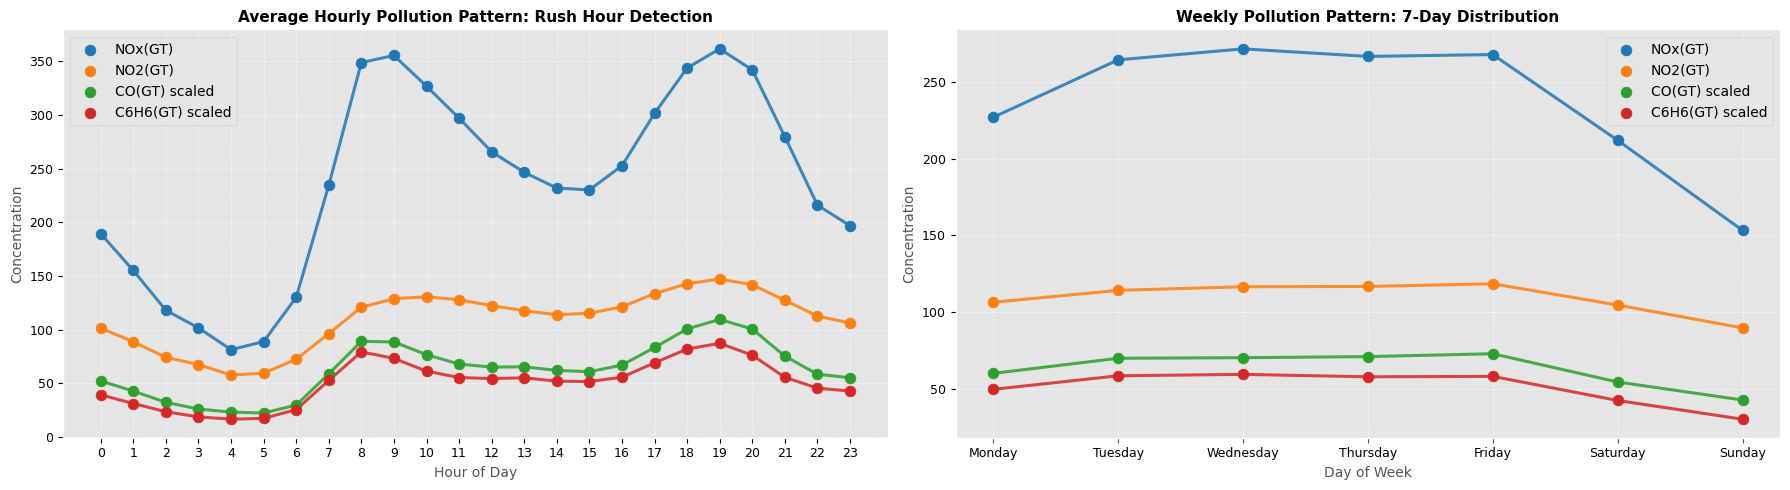

In [12]:
def hourly_daily_pollution_pattern(df_cleaned):
    # --- Hourly data ---
    df_cleaned['Hour'] = df_cleaned.index.hour
    hourly = df_cleaned.groupby('Hour')[['NOx(GT)', 'NO2(GT)', 'CO(GT)', 'C6H6(GT)']].mean()
    hourly['CO_scaled']   = hourly['CO(GT)']   * 30
    hourly['C6H6_scaled'] = hourly['C6H6(GT)'] * 5

    # --- Daily data ---
    df_cleaned['Day'] = df_cleaned.index.day_name()
    daily_avg = df_cleaned.groupby('Day')[['NOx(GT)', 'NO2(GT)', 'CO(GT)', 'C6H6(GT)']].mean()
    ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily_avg = daily_avg.reindex(ordered_days)
    daily_avg['CO_scaled']   = daily_avg['CO(GT)']   * 30
    daily_avg['C6H6_scaled'] = daily_avg['C6H6(GT)'] * 5

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    scatter_kw = dict(s=60, zorder=3)
    line_kw    = dict(linewidth=2.2, alpha=0.85)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

    # ── Left plot: Hourly ──────────────────────────────────────────────────
    for col, label, c in zip(
        ['NOx(GT)', 'NO2(GT)', 'CO_scaled', 'C6H6_scaled'],['NOx(GT)', 'NO2(GT)', 'CO(GT) scaled', 'C6H6(GT) scaled'], 
        colors):
        ax1.plot(hourly.index, hourly[col], color=c, **line_kw)
        ax1.scatter(hourly.index, hourly[col], color=c, label=label, **scatter_kw)

    ax1.set_title("Average Hourly Pollution Pattern: Rush Hour Detection", fontweight='bold', fontsize=11)
    ax1.set_xlabel("Hour of Day", fontsize=10)
    ax1.set_ylabel("Concentration", fontsize=10)
    ax1.set_xticks(range(0, 24))
    ax1.tick_params(axis='both', labelsize=9, colors='black')
    ax1.legend(frameon=True, fontsize=10)
    ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # ── Right plot: Daily ──────────────────────────────────────────────────
    x_pos = range(len(ordered_days))

    for col, label, c in zip( ['NOx(GT)', 'NO2(GT)', 'CO_scaled', 'C6H6_scaled'],['NOx(GT)', 'NO2(GT)', 'CO(GT) scaled', 'C6H6(GT) scaled'],
                             colors):
        ax2.plot(x_pos, daily_avg[col], color=c, **line_kw)
        ax2.scatter(x_pos, daily_avg[col], color=c, label=label, **scatter_kw)

    ax2.set_title("Weekly Pollution Pattern: 7-Day Distribution", fontweight='bold', fontsize=11)
    ax2.set_xlabel("Day of Week", fontsize=10)
    ax2.set_ylabel("Concentration", fontsize=10)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(ordered_days, fontsize=9, color='black')
    ax2.tick_params(axis='y', labelsize=9, colors='black')
    ax2.legend(frameon=True, fontsize=10)
    ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

hourly_daily_pollution_pattern(df_cleaned);

>Interpretation:
>
> Two distinct peaks are observed in hourly pollution pattern:
>- **Morning peak (approximately 7–9 AM)**
>- **Evening peak (approximately 6–9 PM)**
>
> **These peaks correspond to typical urban rush-hour periods, when vehicle activity is highest. The simultaneous rise in CO(GT), NOx(GT), NO₂(GT), and C6H6(GT) during these hours confirms that traffic combustion is the dominant emission source in the dataset.**
>
> **The consistent pattern across all gases further supports the strong inter-correlation observed in the above heatmap and also validates the presence of a shared emission source.**
>
> **The weekly distribution shows consistently higher pollutant concentrations during working days, with a noticeable decline on weekends, particularly Sunday. The synchronized behavior across all gases further confirms traffic-related emission dominance.**
---

####  <font color = blue> **5: Seasonal Variation in Pollutant Levels** </font>

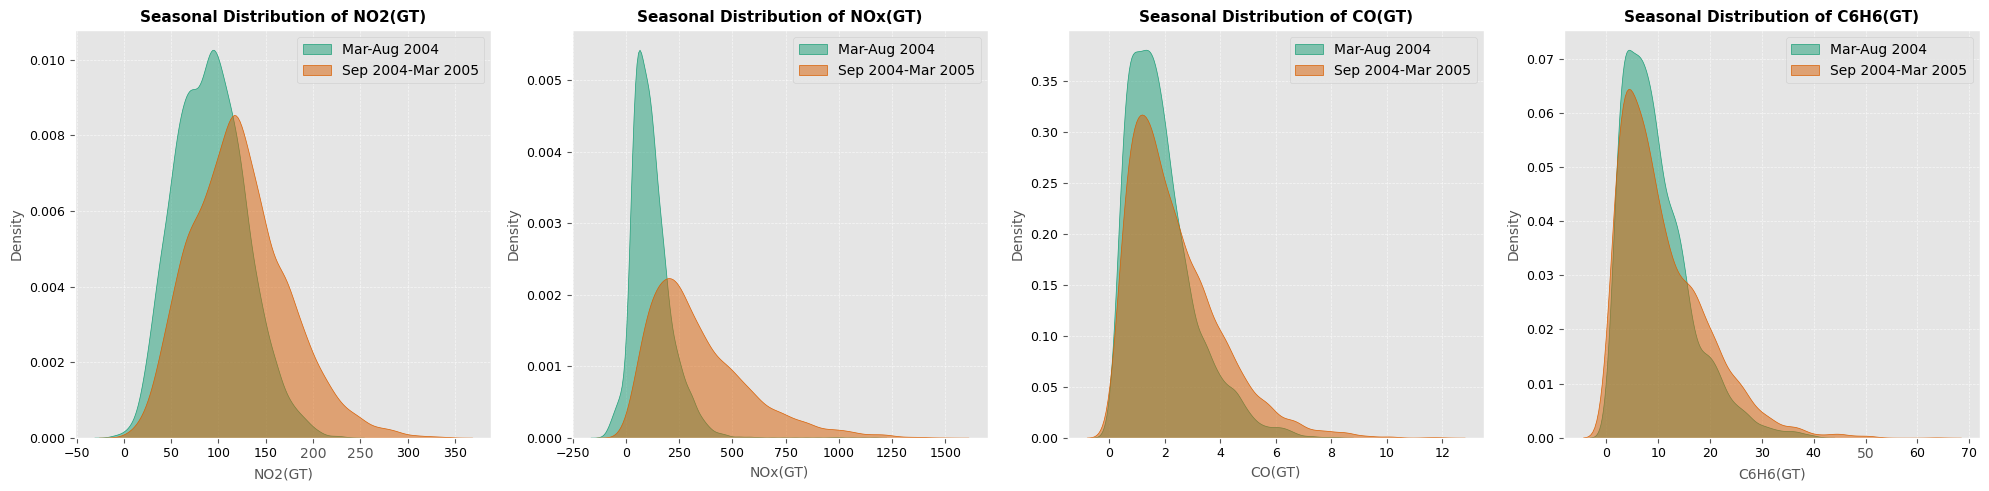

In [13]:
def seasonal_kde_plots(df_cleaned):

    df_cleaned.index = pd.to_datetime(df_cleaned.index)

    # Split periods
    period1 = df_cleaned['2004-03':'2004-08']
    period2 = df_cleaned['2004-09':'2005-02']

    gases = ['NO2(GT)', 'NOx(GT)', 'CO(GT)', 'C6H6(GT)']
    colors = sns.color_palette("Dark2", 2)
    plt.figure(figsize=(20,5))
    for i, gas in enumerate(gases, 1):
        plt.subplot(1,4,i)
        sns.kdeplot(period1[gas], fill=True, alpha=0.5, color=colors[0], label='Mar-Aug 2004')
        sns.kdeplot(period2[gas], fill=True, alpha=0.5, color=colors[1], label='Sep 2004-Mar 2005')
        plt.title(f"Seasonal Distribution of {gas}", fontsize=11, fontweight='bold')
        plt.xlabel(gas, fontsize=10)
        plt.ylabel("Density", fontsize=10)
        plt.legend(frameon=True, fontsize=10)
        plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        plt.xticks(fontsize=9, color='black')    
        plt.yticks(fontsize=9, color='black')

    plt.tight_layout()
    plt.show()
    
seasonal_kde_plots(df_cleaned);

> Intepretation:
>
> **All four GT gases (NO₂, NOx, CO, C6H6) show a clear rightward shift in Sep 2004–Mar 2005, indicating higher and more volatile pollution levels in winter.**
>
> **NO₂ & NOx: Combustion signals flatten and stretch, showing dramatic seasonal changes.**
>
> **CO & C6H6: Traffic-related peaks stay similar, but winter produces more extreme pollution events.**
---

####  <font color = blue> **6: Distribution and Outlier Analysis** </font>


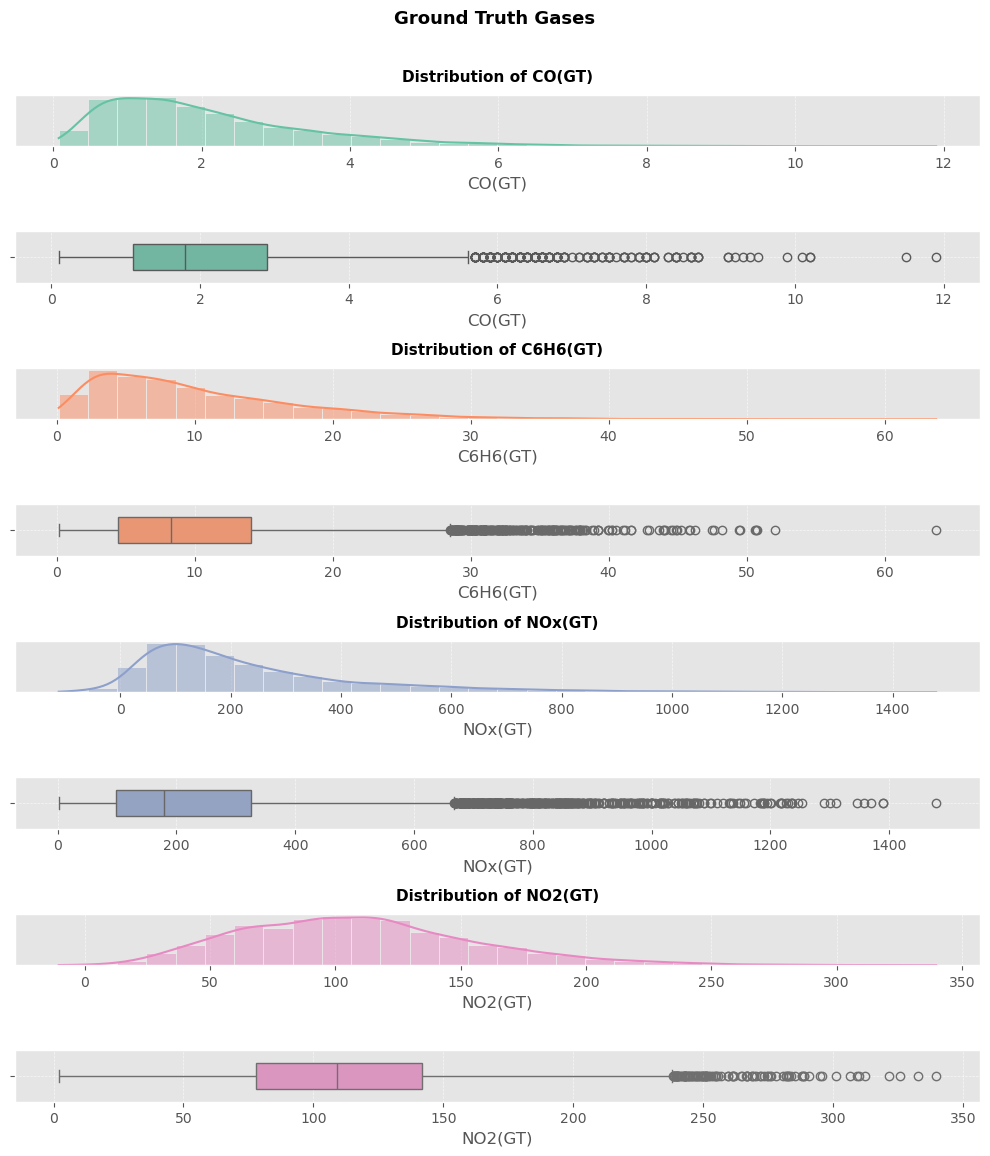

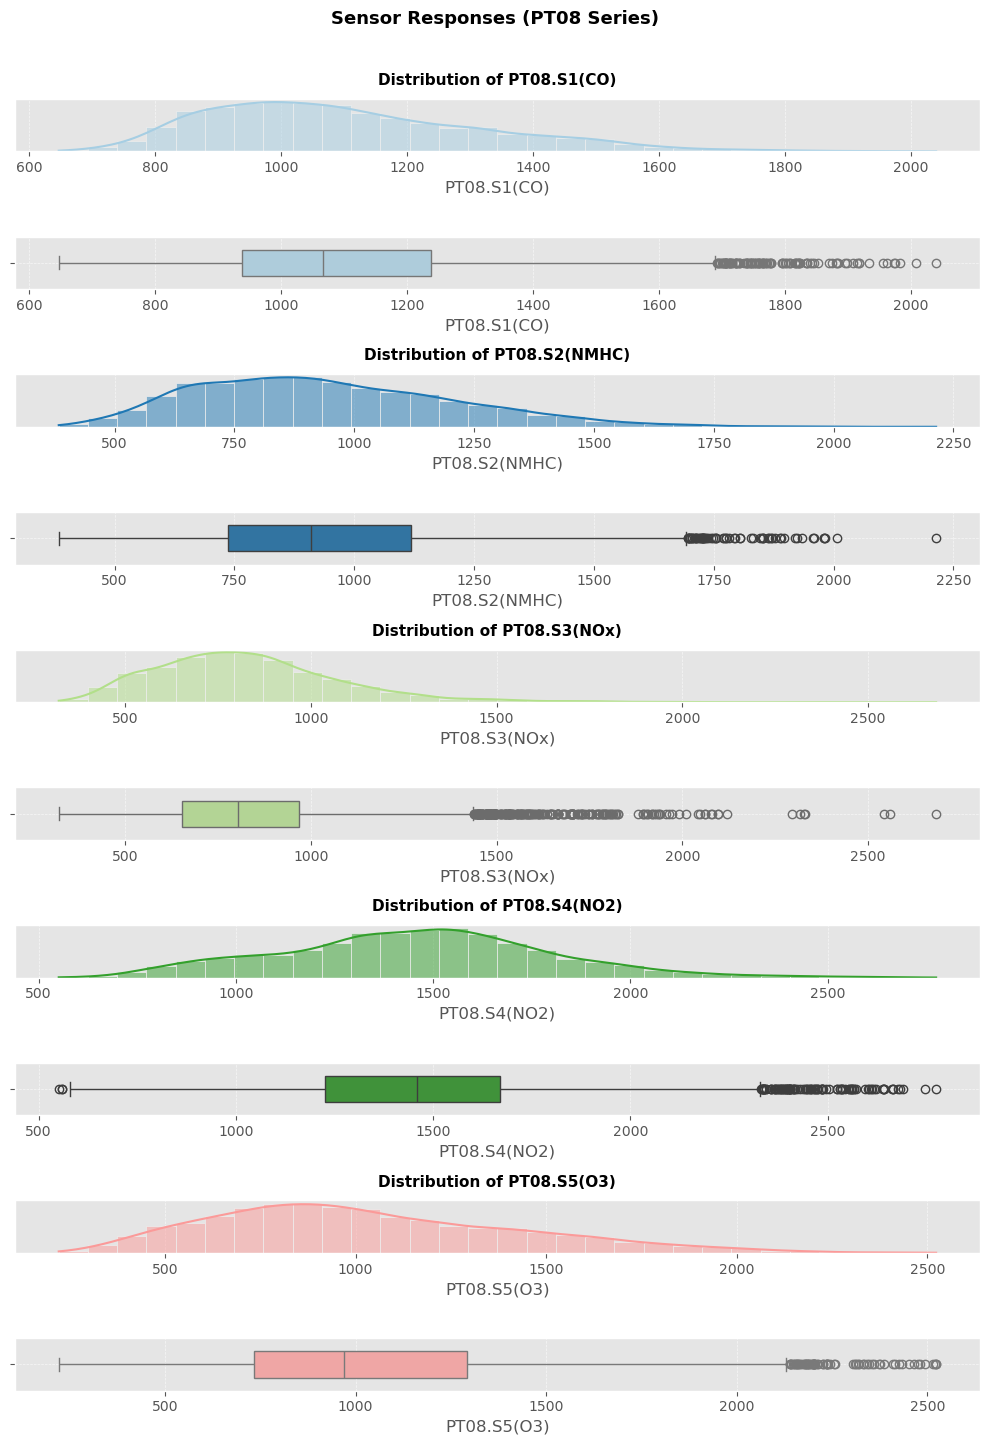

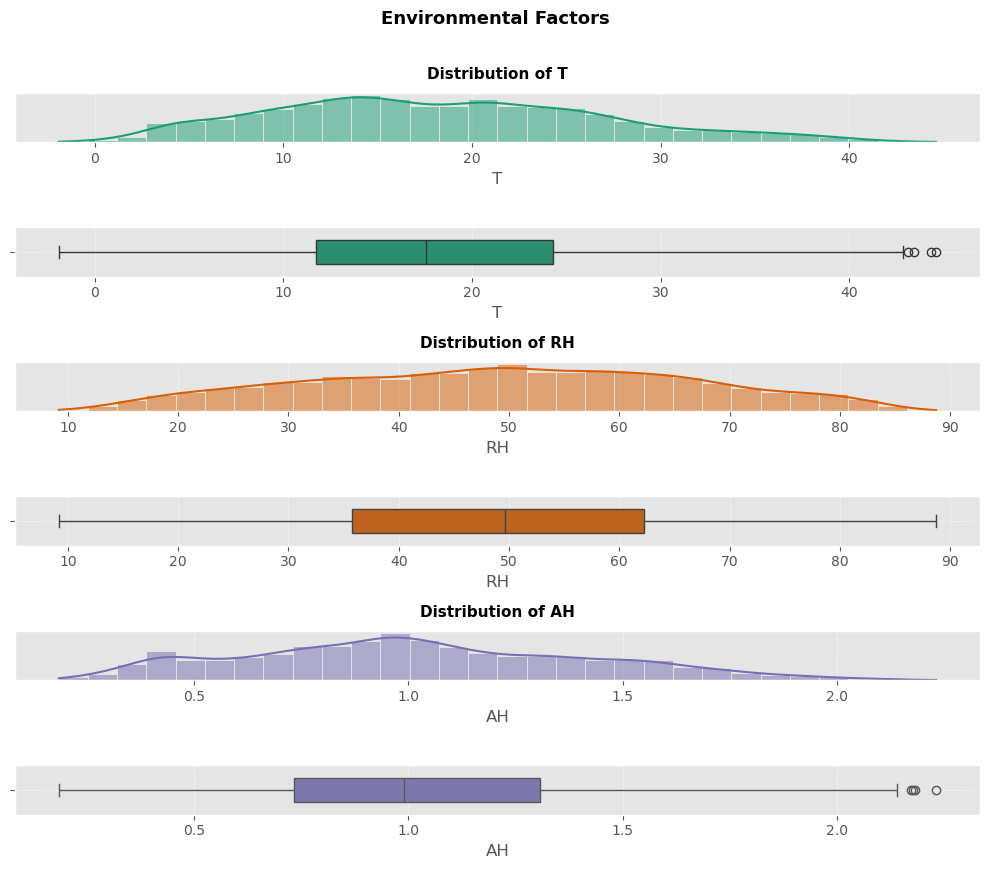

In [14]:
def plot_feature_distributions(df_cleaned, figsize_per_feature=3):

    # Define feature groups
    gt_gases = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
    sensors = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
    env_factors = ['T', 'RH', 'AH']
    
    groups = {
    'Ground Truth Gases': {'features': gt_gases, 'palette': sns.color_palette("Set2", len(gt_gases))},
    'Sensor Responses (PT08 Series)': {'features': sensors, 'palette': sns.color_palette("Paired", len(sensors))},
    'Environmental Factors': {'features': env_factors, 'palette': sns.color_palette("Dark2", len(env_factors))}}

    for group_name, group_info in groups.items():
        features = group_info['features']
        palette = group_info['palette']
        n_features = len(features)

        fig, axes = plt.subplots(nrows=n_features * 2, ncols=1, figsize=(10, n_features* figsize_per_feature))
        fig.suptitle(f'{group_name}', fontsize=13, fontweight='bold', y=0.99)

        if n_features == 1:
            axes = [axes[0], axes[1]]

        for i, (feature, color) in enumerate(zip(features, palette)):

            # Histogram + KDE (top)
            ax_hist = axes[i*2]
            sns.histplot(df_cleaned[feature], kde=True, ax=ax_hist, color=color, bins=30)
            ax_hist.set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold', pad=10)
            ax_hist.set_ylabel("")
            ax_hist.set_yticks([])
            ax_hist.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

            # Boxplot (bottom)
            ax_box = axes[i*2 + 1]
            sns.boxplot(x=df[feature], ax=ax_box, color=color, width=0.5, orient='h')
            ax_box.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.savefig(f"{group_name.replace(' ', '_')}.png")
        plt.show()

plot_feature_distributions(df_cleaned);

> Interpretation:
>
> **All four gases (CO(GT), NOx(GT), NO2(GT), and C6H6(GT)) exhibit noticeable right-skewness, with high-end outliers. These extreme values often reflect real-world pollution events (e.g., heavy traffic, stagnant weather).**
>
> **Sensor distributions generally follow their corresponding GT gases but show slightly wider spreads. PT08.S4 (NO₂ Sensor) shows a few very low outliers, likely caused by sensor malfunctions rather than real events.**
>
> **Environmental factors are mostly stable. Temperature (T) and Absolute Humidity (AH) display some values within range on both extremes, but these could be mostly technical anomalies.**

### <font color = #41EA46> **5: Handling Outliers**<font>

####  <font color = blue> **Winsorization** </font>

The dataset contains extreme values in several ground truth pollutants and sensor responses, as observed in the above boxplots and histograms. These high-end outliers are largely attributable to real-world pollution spikes caused by traffic congestion, atmospheric stagnation, or seasonal effects rather than measurement errors. Removing such observations would disrupt the temporal continuity of the hourly time-series data and eliminate meaningful environmental events.However, since clustering methods such as K-Means rely on Euclidean distance, extreme values can disproportionately influence centroid placement and distort cluster structure. 

Winsorization based on IQR provides a balanced solution by capping extreme values at defined percentile thresholds (e.g., 5th–95th percentile), thereby limiting their mathematical influence while preserving all observations in the dataset.

In [15]:
def winsorize_iqr(df_cleaned):
    # Create a copy of original dataset
    df_wins = df_cleaned.copy() 
    # Remove non-continuous/time-based columns that are not needed for outlier treatment
    df_wins= df_wins.drop(columns=["Day","Hour"])
    
    features = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)','PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)','PT08.S4(NO2)', 'PT08.S5(O3)']

    # Apply IQR-based Winsorization for each featur
    for col in features:
        # Compute first and third quartiles
        Q1 = df_wins[col].quantile(0.25)
        Q3 = df_wins[col].quantile(0.75)
        
        # Interquartile range
        IQR = Q3 - Q1

        # Define lower and upper bounds for outlier capping
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values below lower bound
        df_wins[col] = np.where(df_wins[col] < lower_bound, lower_bound, df_wins[col])
        # Cap values above upper bound
        df_wins[col] = np.where(df_wins[col] > upper_bound, upper_bound, df_wins[col])

    return df_wins

df_wins = winsorize_iqr(df_cleaned)

### <font color = #41EA46> **6: Feature Scaling and Transformation**<font>

####  <font color = blue> **Log Transformation** </font>

Following Winsorization, a logarithmic transformation was applied to highly right-skewed variables. Although Winsorization limits the influence of extreme values by capping them at statistical boundaries, it does not fully address the inherent positive skewness present in the data. 

Pollution doesn't increase linearly; it often increases exponentially. Therefore, log transformation compresses the scale of these large values while preserving the order of observations, thereby stabilizing variance and producing a more symmetric distribution. This improves the suitability of the data for distance-based methods such as K-means clustering and variance-based techniques such as PCA, both of which are sensitive to scale and skewness.

In [16]:
def log_transform(df_wins):
    # Create a copy of original dataset
    df_log = df_wins.copy()
    
    features = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)','PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)','PT08.S4(NO2)', 'PT08.S5(O3)']

    # Apply log transformation to reduce skewness in distributions
    for col in features:
        #Clip any values below 0 to exactly 0
        df_log[col] = df_log[col].clip(lower=0)
        # log(1 + x) stabilizes variance and handles zero values safely
        df_log[col] = np.log1p(df_log[col])

    # Handle any missing values created during transformation
    df_log = df_log.fillna(0)
    
    return df_log

df_log = log_transform(df_wins)

####  <font color = blue> **Feature Scaling** </font>

Scaling was applied to standardize variables measured in different units and magnitudes. The RobustScaler was selected since it uses the median and interquartile range (IQR), unlike the StandardScaler, which uses the mean.  This ensures stability and prevents high-magnitude sensor readings from dominating clustering and dimensionality reduction results.


In [17]:
def scale_data(df_log):

    scaler = RobustScaler()
     # Fit scaler on data and transform it into scaled numerical values
    scaled_array = scaler.fit_transform(df_log)
    
    # Convert scaled array back into a DataFrame
    df_final = pd.DataFrame(scaled_array, columns=df_log.columns, index=df_log.index)
    
    return df_final, scaler

df_final, scaler = scale_data(df_log)
df_final.head(5)

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,0.440963,0.871701,0.322494,0.330464,-0.039902,0.698533,0.103312,0.481203,0.471661,-0.316733,-0.029301,-0.403472
2004-03-10 19:00:00,0.156909,0.688280,0.111151,0.113711,-0.429504,0.967980,-0.228617,0.214167,0.004085,-0.340637,-0.073724,-0.459647
2004-03-10 20:00:00,0.257459,0.980879,0.072520,0.074641,-0.233379,0.893448,0.117550,0.205279,0.179565,-0.452191,0.163516,-0.416555
2004-03-10 21:00:00,0.257459,0.912380,0.095048,0.097405,-0.010865,0.783560,0.227192,0.265965,0.379931,-0.523904,0.391304,-0.353055
2004-03-10 22:00:00,-0.066040,0.632293,-0.208615,-0.204738,-0.233379,1.035105,0.145660,0.067326,0.237697,-0.511952,0.375236,-0.349431


### <font color = #41EA46> **7: Clustering Model Development & Evaluation**<font>

####  <font color = blue> **Model Development** </font>

Clustering was applied to uncover underlying patterns in urban air quality by grouping similar pollution conditions without predefined labels. After preprocessing the dataset through outlier handling, log transformation, and robust scaling, the K-Means algorithm was implemented separately on two time periods (March–August and September–March) to capture seasonal variations.

**Choosing the Optimal Number of Clusters:** A key step in applying K-Means clustering is selecting an appropriate number of clusters (k), as this directly affects the quality and interpretability of the resulting groups. To identify the optimal value of k, the Elbow Method was used

In [19]:
# Define Period 1 (Mar - Aug 2004)
df_p1 = df_final.loc['2004-03':'2004-08']
dfMatrix = df_p1.to_numpy()

# Choose Optimal K (The Elbow Method)
cost = []
for cluster in range(1, 11):
    # Initialize KMeans with k-means++ for better centroid initialization
    kmeans = KMeans(n_clusters=cluster, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(dfMatrix)
    cost.append(kmeans.inertia_)
    print(f'Cluster initiation: {cluster}')

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6
Cluster initiation: 7
Cluster initiation: 8
Cluster initiation: 9
Cluster initiation: 10


In [20]:
# Create a DataFrame to store K values and their corresponding clustering cost (inertia)
df_cost = pd.DataFrame({'Cluster': range(1, 11), 'Cost': cost})
df_cost.head(5)

,Cluster,Cost
0,1,21898.276460
1,2,12699.973749
2,3,10145.653299
3,4,8698.923079
4,5,7608.745169


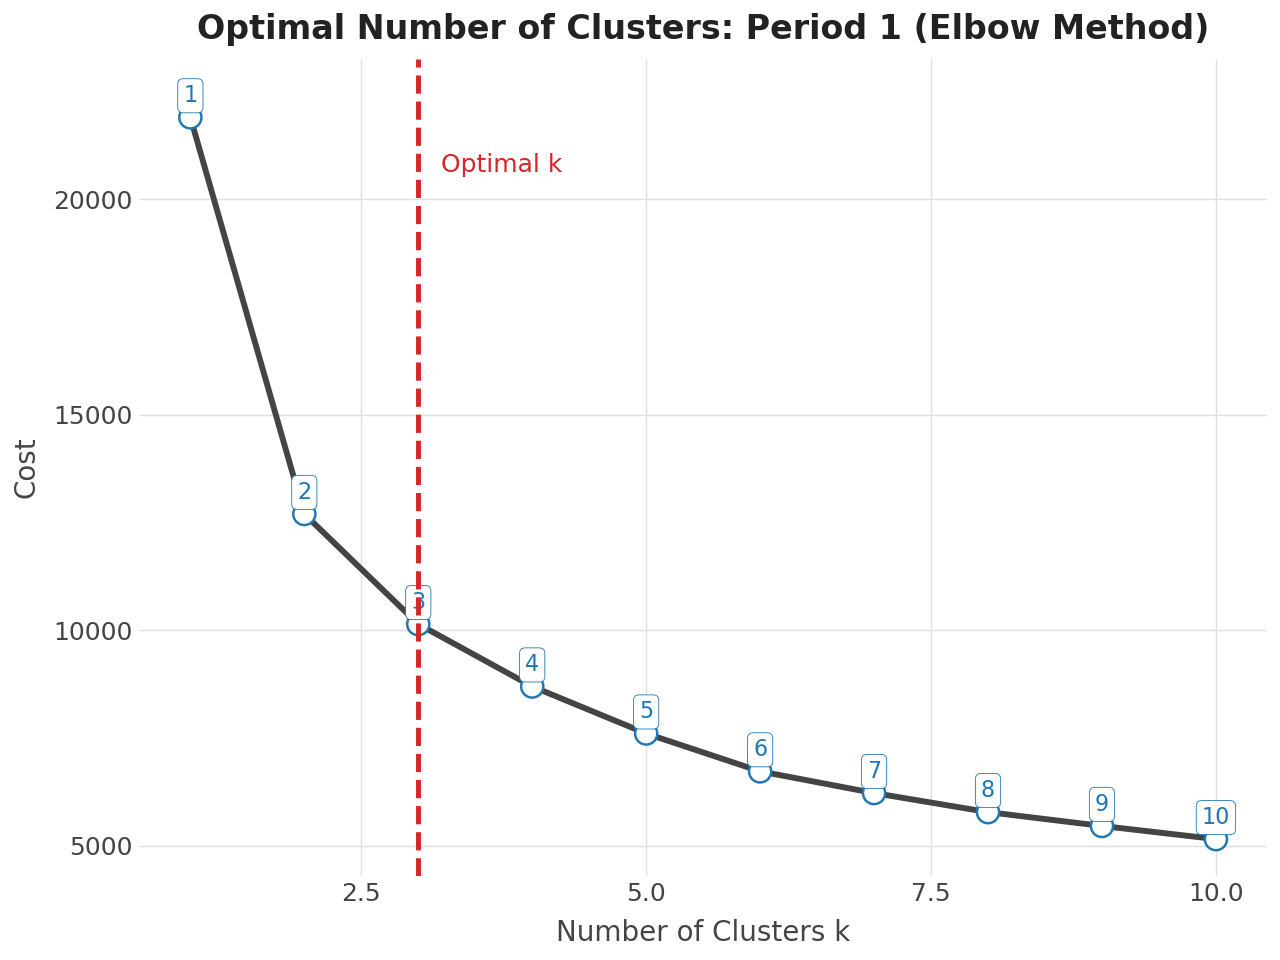

In [21]:
# Elbow Method Plot
plot = (
    # Base plot using cost vs number of clusters
    ggplot(data=df_cost) +
    # Line plot showing how clustering cost changes with k
    geom_line(aes(x='Cluster', y='Cost'), color='#444444', size=1.2) +
    # Highlight individual cost points for each k
    geom_point(aes(x='Cluster', y='Cost'), color='#1f77b4', size=4, fill='white') +
    
    geom_label(aes(x='Cluster', y='Cost', label='Cluster'), size=8, nudge_y=500,color='#1f77b4',  fill='white',label_size=0.3) +
    # Vertical reference line indicating selected optimal k
    geom_vline(xintercept=3, linetype='dashed', color='#d62728', size=1.0) +
    # Annotation marking the optimal cluster choice
    annotate('text', x=3.2, y=df_cost['Cost'].max() * 0.95, label='Optimal k', color='#d62728', size=9, ha='left') +
    
    labs(title='Optimal Number of Clusters: Period 1 (Elbow Method)') +
    xlab('Number of Clusters k') +
    ylab('Cost') +
    theme_minimal() +
    theme(
        plot_title=element_text(face='bold', size=12, color='#222222'),
        axis_title=element_text(size=10, color='#444444'),
        axis_text=element_text(size=9, color='#444444'),
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(color='#e0e0e0', size=0.5)
    )
)
plot

> Interpretation:
>
> **k=3**
>
> **The "Elbow" Point: There is a distinct "bend" at k=3. Before this point, the cost drops drastically; after this point, the gains from adding more clusters become much smaller.**
> 
> **The optimal number of clusters (k) was determined using the Elbow Method on the first time period. The same value of k was applied to the second period to ensure consistency in cluster structure. This enables meaningful comparison of cluster centroids and distributions across time, which is essential for model drift analysis.**

In [22]:
# Define Period 2 (Sep 2004 - March 2005)
df_p2 = df_final.loc['2004-09':'2005-03']

# Use the k found from the Period 1 Elbow plot
k_optimal = 3 

# Fit Model 1 (Period 1)
kmeans_p1 = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
labels_p1 = kmeans_p1.fit_predict(df_p1.to_numpy())

# Fit Model 2 (Period 2)
kmeans_p2 = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
labels_p2 = kmeans_p2.fit_predict(df_p2.to_numpy())

In [23]:
# Apply labels to Period 1
df_p1['Cluster Labels'] = labels_p1 # From your kmeans_p1.fit_predict
df_p1['Segment'] = df_p1['Cluster Labels'].map({0:'Cluster_0', 1:'Cluster_1', 2:'Cluster_2'})

# Apply labels to Period 2
df_p2['Cluster Labels'] = labels_p2 # From your kmeans_p2.fit_predict
df_p2['Segment'] = df_p2['Cluster Labels'].map({0:'Cluster_0', 1:'Cluster_1', 2:'Cluster_2'})

####  <font color = blue> **Cluster Evaluation** </font>

The performance of the K-Means clustering model was evaluated using multiple internal validation metrics such as Silhouette Score, Davies–Bouldin Index, and Calinski–Harabasz Score to assess cluster quality, compactness, and separation across the two time periods.


In [24]:
sil_p1 = silhouette_score(df_p1.drop(columns=['Cluster Labels', 'Segment']), labels_p1)
sil_p2 = silhouette_score(df_p2.drop(columns=['Cluster Labels', 'Segment']), labels_p2)

print(f"Silhouette Score (Period 1): {sil_p1:.4f}")
print(f"Silhouette Score (Period 2): {sil_p2:.4f}")

Silhouette Score (Period 1): 0.2558
Silhouette Score (Period 2): 0.2676


In [25]:
dbi_p1 = davies_bouldin_score(df_p1.drop(columns=['Cluster Labels', 'Segment']), labels_p1)
dbi_p2 = davies_bouldin_score(df_p2.drop(columns=['Cluster Labels', 'Segment']), labels_p2)

print(f"Davies–Bouldin Index (Period 1): {dbi_p1:.4f}")
print(f"Davies–Bouldin Index (Period 2): {dbi_p2:.4f}")

Davies–Bouldin Index (Period 1): 1.2724
Davies–Bouldin Index (Period 2): 1.2786


In [26]:
ch_p1 = calinski_harabasz_score(df_p1.drop(columns=['Cluster Labels', 'Segment']), labels_p1)
ch_p2 = calinski_harabasz_score(df_p2.drop(columns=['Cluster Labels', 'Segment']), labels_p2)

print(f"Calinski–Harabasz Score (Period 1): {ch_p1:.4f}")
print(f"Calinski–Harabasz Score (Period 2): {ch_p2:.4f}")

Calinski–Harabasz Score (Period 1): 2420.4594
Calinski–Harabasz Score (Period 2): 3296.9568


> **The Silhouette Scores (0.2558 for Period 1 and 0.2676 for Period 2) indicate weak but meaningful cluster separation, which is expected for air quality data where pollutant levels vary continuously rather than forming clearly distinct groups.**
>
> **The Davies–Bouldin Index values (~1.27 for both periods) suggest reasonable cluster compactness and separation, with no significant degradation between the two periods.**
>
> **The Calinski–Harabasz Scores (2420 → 3296) show a notable increase in Period 2, indicating improved cluster separation and more distinct group structure.**

---
### <font color = #41EA46> **8: Model Drift Analysis**<font>

Model drift analysis was conducted to examine how air quality patterns change over time and to assess whether clusters learned in one period remain consistent in another. Since the dataset spans different seasons, underlying data distributions are expected to shift due to environmental and human factors. 

To capture this, clustering results from the two periods were compared using centroid shifts, cluster membership changes, and statistical measures such as KL divergence.

####  <font color = blue> **Centroid Shift** </font>

Centroid shift analysis was performed to measure how the characteristics of each cluster change between the two time periods. In K-Means clustering, centroids represent the average feature values of each cluster; therefore, any movement in these centroids reflects changes in the underlying pollution patterns.

In [27]:
# Create Centroid Table for Period 1
centroids_p1 = pd.DataFrame(kmeans_p1.cluster_centers_, columns=df_p1.columns[:-2], index=['Cluster 0', 'Cluster 1', 'Cluster 2'])
centroids_p1

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Cluster 0,-0.815599,-0.786755,-0.910275,-0.870599,-1.967839,0.963003,-1.464459,-0.232308,-0.960210,0.210423,0.008310,0.281701
Cluster 1,-0.171886,-0.177936,-0.128652,-0.123806,-0.582316,0.295378,-0.405789,0.174213,-0.303041,0.488895,-0.265347,0.331950
Cluster 2,0.631062,0.629753,0.611725,0.646564,0.112766,-0.340914,0.295659,0.791149,0.485511,0.530296,-0.389750,0.203229


In [28]:
# Create Centroid Table for Period 2
centroids_p2 = pd.DataFrame(kmeans_p2.cluster_centers_,  columns=df_p2.columns[:-2],  index=['Cluster 0', 'Cluster 1', 'Cluster 2'])
centroids_p2

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Cluster 0,-0.661578,-0.725242,-0.969100,-0.927269,-0.397400,0.713893,-0.666481,-1.258031,-0.842772,-0.526077,0.180595,-0.392195
Cluster 1,0.860282,0.909006,0.734973,0.786784,0.853268,-1.060015,0.552464,0.418966,0.821520,-0.024686,0.233088,0.208818
Cluster 2,0.036635,0.017768,-0.072320,-0.067996,0.332147,-0.167533,0.205308,-0.600428,0.096020,-0.307255,0.143791,-0.222146


K-means starts with random seeds; it does NOT guarantee cluster order.

- In Period 1, the "High Pollution" cluster might be labeled 0.
- In Period 2, the "High Pollution" cluster might be labeled 2.

Therefore subtracting them without matching them first isn't measuring drift. First, clusters should match based on similarity (distance between centroids).

In [29]:
# Compute distance matrix
distance_matrix = cdist(kmeans_p1.cluster_centers_, kmeans_p2.cluster_centers_)

# Find best matching clusters
matching = np.argmin(distance_matrix, axis=1)

print("Cluster Matching:", matching)

Cluster Matching: [0 2 1]


> Interpretation:
>
> P1 Cluster 0 → P2 Cluster 1
> 
> P1 Cluster 1 → P2 Cluster 0
> 
> P1 Cluster 2 → P2 Cluster 2
>
> **This confirms that K-means reordered clusters across different runs. Therefore, clusters from the two periods were aligned based on minimum centroid distance before computing the shift. This ensures that comparable clusters are correctly matched for drift analysis.**

In [30]:
# Reorder Period 2 Centroids
centroids_p2_matched = kmeans_p2.cluster_centers_[matching]

# Measure the Shift
centroid_shift = centroids_p2_matched - kmeans_p1.cluster_centers_
centroid_shift_df = pd.DataFrame( centroid_shift, columns=df_p1.columns[:-2], index=['Cluster 0', 'Cluster 1', 'Cluster 2'])
centroid_shift_df

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Cluster 0,0.154021,0.061513,-0.058825,-0.05667,1.570439,-0.249109,0.797978,-1.025723,0.117439,-0.736500,0.172285,-0.673896
Cluster 1,0.208522,0.195704,0.056332,0.05581,0.914463,-0.462911,0.611097,-0.774640,0.399061,-0.796150,0.409138,-0.554096
Cluster 2,0.229220,0.279254,0.123248,0.14022,0.740503,-0.719101,0.256805,-0.372184,0.336009,-0.554982,0.622838,0.005589


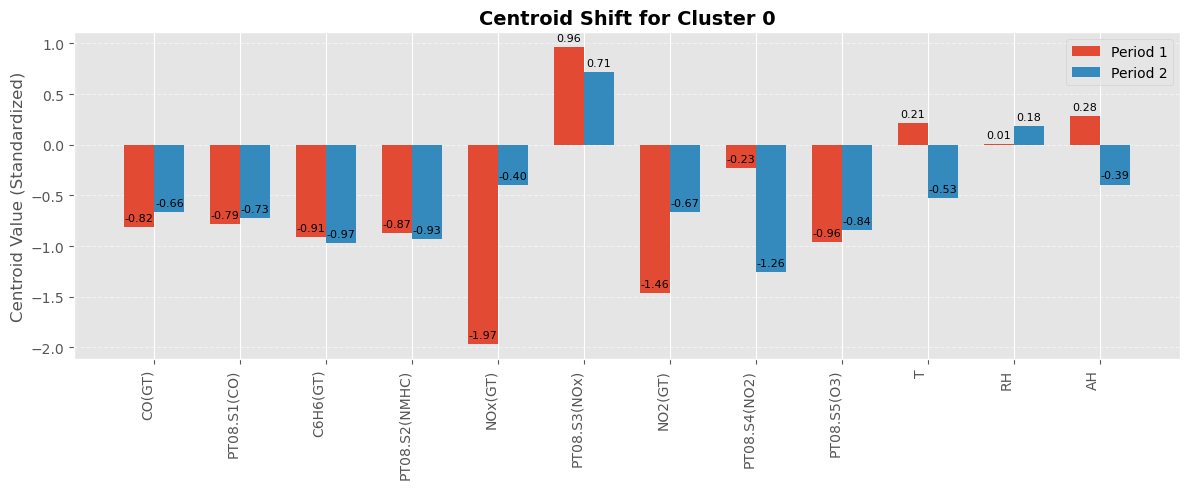

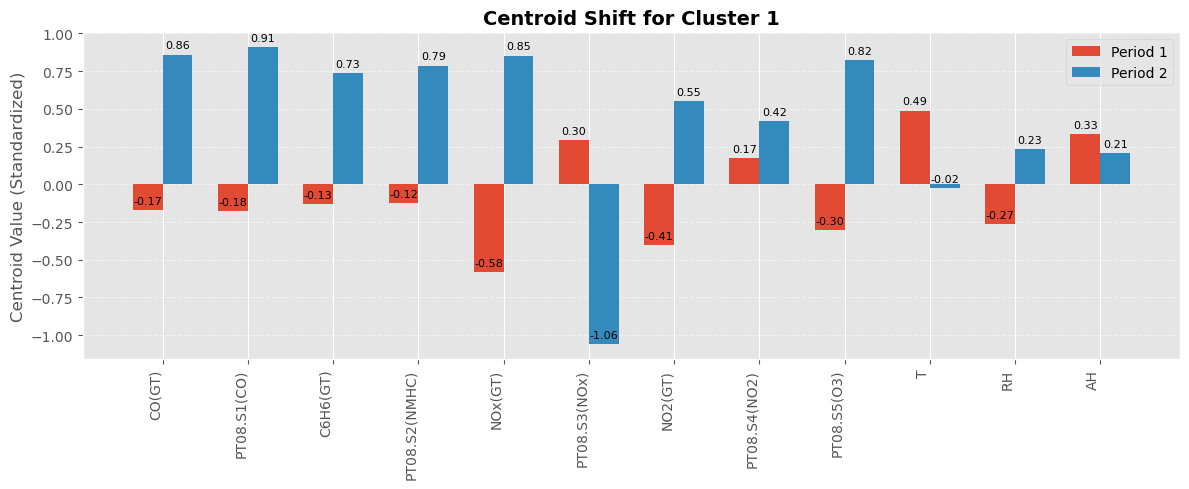

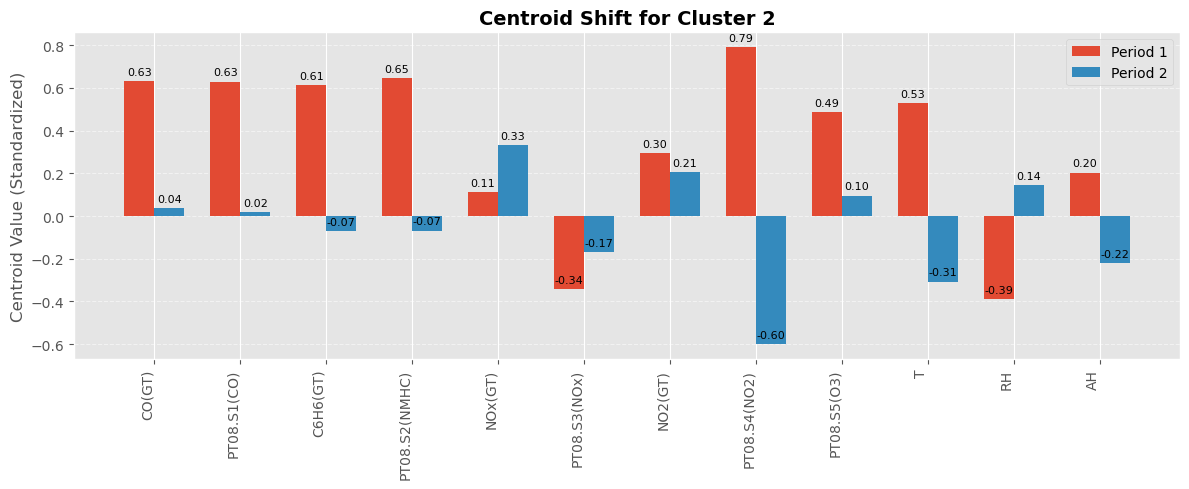

In [31]:
def plot_centroid_shifts(centroids_p1, centroids_p2):

    clusters = centroids_p1.index
    features = centroids_p1.columns
    x = np.arange(len(features)) 
    width = 0.35  

    for cluster in clusters:
        fig, ax = plt.subplots(figsize=(12, 5))
        bars1 = ax.bar(x - width/2, centroids_p1.loc[cluster], width, label='Period 1')
        bars2 = ax.bar(x + width/2, centroids_p2.loc[cluster], width, label='Period 2')
        
        for bar in bars1 + bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3),  textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
            
        ax.set_xticks(x)
        ax.set_xticklabels(features, rotation=90, ha='right')
        ax.set_ylabel('Centroid Value (Standardized)')
        ax.set_title(f'Centroid Shift for {cluster}', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

plot_centroid_shifts(centroids_p1, centroids_p2);

> Interpretation:
>
> **Cluster 0 (High Pollution Conditions)**
>
> - Cluster 0 shows a strong increase in NOx (GT) (+1.57) and NO₂ (GT) (+0.80), indicating a clear rise in traffic-related and combustion emissions during Period 2. CO levels also increase slightly, reinforcing higher overall pollution intensity.
>
> - At the same time, temperature (-0.74) and absolute humidity (-0.67) decrease, suggesting colder and drier conditions that reduce atmospheric dispersion and promote pollutant accumulation.
>
> - The strong negative shift in PT08.S4(NO₂) further indicates that sensor responses are influenced by changing environmental conditions.
>
> **Cluster 1 (Moderate Conditions)**
>
> - Cluster 1 shows moderate increases in CO, benzene (C₆H₆), and particulate sensor readings (PT08 series).
> 
> - This is accompanied by a noticeable decrease in temperature (-0.80) and a moderate increase in relative humidity (+0.41).
>
> - These changes suggest that previously stable moderate air quality conditions are shifting toward more variable and slightly more polluted atmospheric states in Period 2.
>
> **Cluster 2 (Low Pollution Conditions)**
>
> - Cluster 2 shows smaller increases in pollutant indicators such as CO and non-methane hydrocarbon (NMHC) sensor readings.
> 
> - It exhibits increases in both relative humidity (+0.62) and a slight rise in absolute humidity (+0.005). This indicates more moisture-rich conditions.
>
> - However, despite representing the “cleanest” cluster, it still reflects increased variability in emissions and environmental influence, suggesting that even low-pollution states are becoming less stable.
>
> **These findings confirm a seasonal shift in air quality dynamics, where winter conditions contribute to higher pollution accumulation and greater instability in air quality states.**
> 
---

####  <font color = blue> **Cluster Membership Changes** </font>

Cluster membership analysis was conducted to examine how the distribution of data points across clusters varies between the two time periods. By comparing the proportion of observations assigned to each cluster, this analysis reveals whether certain air quality conditions (e.g., low, moderate, or high pollution) become more or less dominant over time.


In [32]:
# Period 1 distribution
p1_dist = df_p1['Cluster Labels'].value_counts(normalize=True).sort_index()
# Period 2 distribution
p2_dist = df_p2['Cluster Labels'].value_counts(normalize=True).sort_index()

# Combine the distributions
comparison = pd.DataFrame({ 'Period 1': p1_dist, 'Period 2': p2_dist})
# Absolute change
comparison['Change'] = comparison['Period 2'] - comparison['Period 1']
# Percentage change
comparison['Change (%)'] = (comparison['Change'] / comparison['Period 1']) * 100

comparison = comparison.round(4)
comparison

,Period 1,Period 2,Change,Change (%)
Cluster Labels,,,,
0,0.2073,0.2520,0.0446,21.5363
1,0.4572,0.3333,-0.1239,-27.0921
2,0.3355,0.4147,0.0792,23.6123


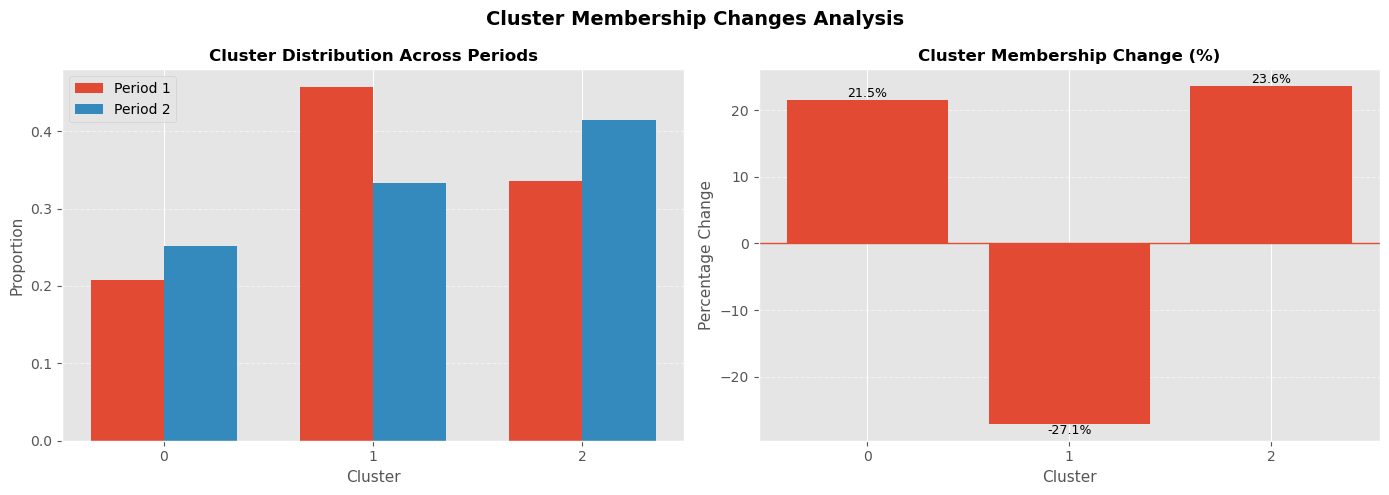

In [33]:
def plot_cluster_membership_changes(comparison):

    clusters = comparison.index.astype(str)
    x = np.arange(len(clusters))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Grouped Bar Chart
    axes[0].bar(x - width/2, comparison['Period 1'], width, label='Period 1')
    axes[0].bar(x + width/2, comparison['Period 2'], width, label='Period 2')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(clusters)
    axes[0].set_xlabel("Cluster", fontsize=11)
    axes[0].set_ylabel("Proportion", fontsize=11)
    axes[0].set_title("Cluster Distribution Across Periods", fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Change (%) Bar Chart
    bars3 = axes[1].bar(clusters, comparison['Change (%)'])
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("Cluster", fontsize=11)
    axes[1].set_ylabel("Percentage Change", fontsize=11)
    axes[1].set_title("Cluster Membership Change (%)", fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    # Add labels
    for bar in bars3:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', ha='center', va='bottom' if height >= 0 else 'top',
                     fontsize=9)
        
    plt.suptitle("Cluster Membership Changes Analysis", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_cluster_membership_changes(comparison);

> Interpretation:
>
> **The results show a clear redistribution of air quality states between the two periods, indicating seasonal drift.**
>
> - **Cluster 1 (moderate conditions) experiences a significant decrease (−27.1%), meaning that average pollution conditions become less frequent.**
> - **Cluster 0 (high pollution) increases by +21.5%, indicating that severe pollution events occur more often in Period 2.**
> - **Cluster 2 (low pollution) also increases (+23.6%), suggesting greater variability, with more occurrences of both cleaner and highly polluted conditions rather than stable moderate states.**
>
> **Overall, this pattern reflects that the air quality shifts away from moderate conditions toward more extreme states, consistent with seasonal influences.**
---
####  <font color = blue> **Kullback-Leibler (KL) Divergence** </font>

Kullback–Leibler (KL) Divergence was used to quantify the difference between the cluster distributions of the two time periods. It is a statistical measure that evaluates how one probability distribution diverges from another reference distribution. In this context, the cluster membership proportions from Period 1 are compared with those from Period 2 to assess how much the overall structure of the data has changed.

In [34]:
kl_div = entropy(p1_dist, p2_dist)
kl_div = kl_div.round(4)

print(kl_div)

0.0329


> Interpretation:
>
> **A KL Divergence value of 0.0329 indicates that the cluster distributions between Period 1 and Period 2 are very similar, with only a small divergence. However, the cluster membership changes reveal substantial shifts at the individual cluster level. Cluster 1 (moderate conditions) decreases by 27.1%, while Cluster 0 (high pollution) and Cluster 2 (low pollution) increase by 21.5% and 23.6%, respectively. This occurs because KL Divergence measures the overall distribution difference, averaging relative probabilities across all clusters.**
>
>  **The low value suggests minimal model drift, implying that the patterns of air quality captured by the clusters have not drastically changed across the two periods.**
---

### <font color = #41EA46> **9: Visualizing Seasonal Drift Using Principal Component Analysis (PCA)**<font>

Principal Component Analysis (PCA) was applied to reduce the 12-dimensional sensor and environmental feature space into two principal components. This dimensionality reduction allows visualizing complex multivariate data on a 2D map while preserving most of the variance. 

By plotting the clusters from Period 1 and Period 2 on the same PCA axes, shifts in cluster positions, overlaps, and expansions can be observed, providing a visual representation of seasonal drift and structural changes in urban air quality.


In [35]:
# X = scaled features (df_final)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_final)

# Store PCA results into a DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df_final.index)

# Initialize Cluster & Period Columns
df_pca['Cluster'] = None
df_pca['Period'] = None

# Assign Cluster Labels for Period 1
df_pca.loc[df_p1.index, 'Cluster'] = df_p1['Cluster Labels']
df_pca.loc[df_p1.index, 'Period'] = 'Period 1'

# Assign Cluster Labels for Period 2
df_pca.loc[df_p2.index, 'Cluster'] = df_p2['Cluster Labels']
df_pca.loc[df_p2.index, 'Period'] = 'Period 2'

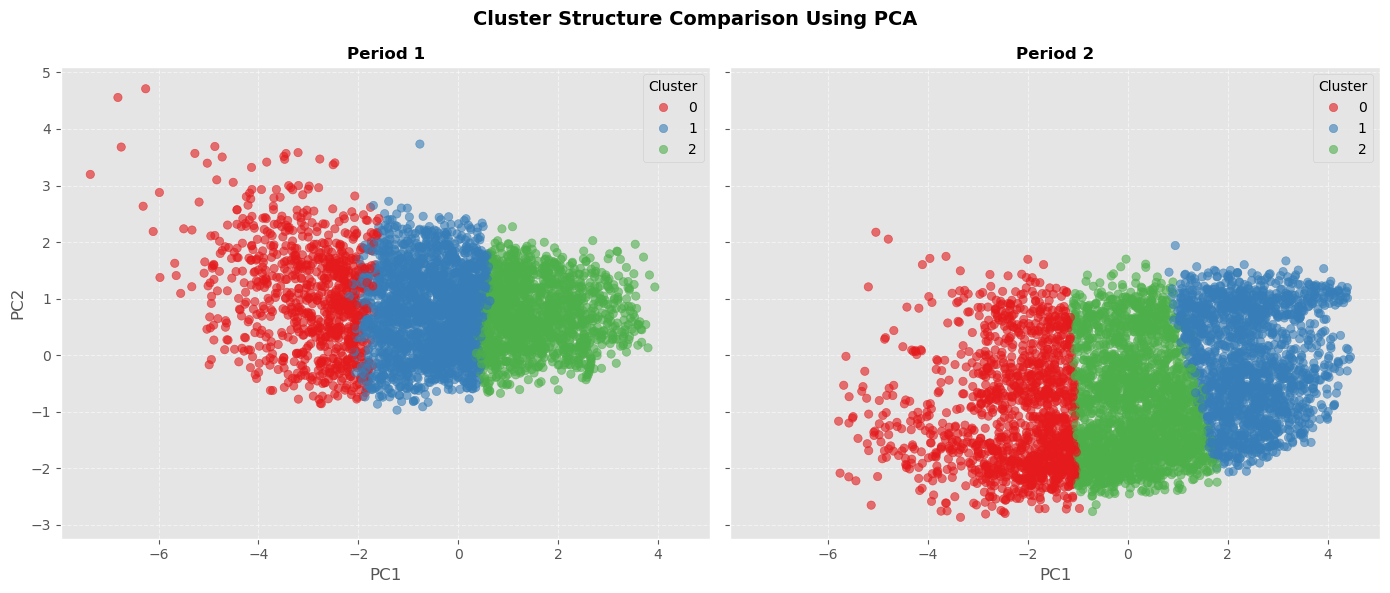

In [36]:
def plot_pca_clusters(df_pca, x='PC1', y='PC2', cluster_col='Cluster', period_col='Period'):

    fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

    periods = sorted(df_pca[period_col].dropna().unique())[:2] 
    
    palette = ['#e41a1c', '#377eb8', '#4daf4a'] 

    for ax, period in zip(axes, periods):
        subset = df_pca[df_pca[period_col] == period]
        sns.scatterplot(data=subset, x=x,  y=y, hue=cluster_col, palette=palette, ax=ax, alpha=0.6, edgecolor=None)
        ax.set_title(f"{period}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title='Cluster', loc='upper right')

    plt.suptitle("Cluster Structure Comparison Using PCA", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
plot_pca_clusters(df_pca);

> Interpretation:
>
> **Horizontal Shift (Shift in Baseline Conditions)**
>
> - The first principal component (PC1) shows a rightward shift from Period 1 to Period 2. In Period 1, clusters are mostly left-leaning, while in Period 2, the data distribution moves to the right.
> 
> - This shift indicates that the baseline atmospheric conditions have changed with the season. Even Low pollution states occupy a different space in winter, providing strong evidence of model drift.
>
> **Expansion of the High-Pollution Cluster**
>
> - Cluster 0, representing high pollution conditions, appears more compact in Period 1 but expands and moves toward the center in Period 2.
> 
> - This expansion indicates that high pollution events become more frequent and more widely distributed during the colder months. It supports earlier findings from centroid shift and cluster membership analyses, which also point to an increase in pollution intensity.
>
> **Changes in Cluster Dominance and Structure**
>
> - In Period 1, Cluster 1 (moderate conditions) dominates the central region. In Period 2, however, Cluster 2 expands into this space, while Cluster 1 shifts to a different region.
> 
> - This reflects structural drift, where the relationships between clusters evolve over time. The characteristics defining moderate air quality in Period 1 are no longer consistent in Period 2, suggesting that cluster boundaries are not stable across seasons.
>
> Overall, the PCA visualization clearly demonstrates that both the structure and distribution of air quality data change between periods. The observed shifts in cluster position, spread, and dominance provide strong evidence of model drift. As a result, a single static model is unlikely to perform consistently across both periods, suggesting the need for period-specific modelling approaches.
>
--- 

### <font color = #41EA46> **10: Conclusion and Insights**<font>




**1. Cluster Variations and Interpretation**

Across both periods, three consistent air quality states were identified:
- Low Pollution
- Moderate Conditions
- High Pollution

However, these states were not fixed in their characteristics. Centroid shift analysis showed that pollutant-dominant clusters, particularly those associated with NOx and CO emissions, intensified during colder months while temperature and absolute humidity decreased. This pattern suggests that winter conditions contribute to pollutant accumulation due to reduced atmospheric dispersion and increased combustion activity.

**2. Centroid Shifts and Seasonal Drift**

Cluster membership analysis further confirmed a redistribution of air quality states over time. The moderate pollution cluster declined significantly, while both low and high pollution clusters increased. This indicates a shift away from stable atmospheric conditions toward more extreme and variable air quality states. KL divergence supported this observation by showing limited overall distributional change, suggesting that while the global cluster structure remained broadly consistent, meaningful internal redistribution occurred within clusters.

PCA-based visualization reinforced these findings by revealing clear seasonal drift in the feature space. Changes in cluster positions, boundaries, and densities between periods confirm that the underlying data distribution is not stationary. This indicates moderate model drift, meaning a model trained on one period may not generalize reliably to another without adjustment.

**3. Environment and Socio-Economic Implications**

From a broader perspective, these patterns can be linked to environmental and socio-economic factors.

- **Higher Pollution in Winter:** Increased heating demand and higher energy consumption, combined with atmospheric inversion conditions, likely contribute to more frequent high-pollution events during colder months.
- **Traffic and Industrial Activity:** Seasonal variations in vehicle usage and industrial output also contribute to the observed shifts in clusters reinforcing changes in emission intensity across periods.
- **Public Health Implications:** The increase in high-pollution periods during colder months highlights the need for targeted interventions, such as traffic regulation measures and industrial emission controls, to reduce exposure and protect public health.

The decline in moderate conditions further suggests a transition toward more unstable environmental states, where seasonal weather patterns and human activity exert stronger influence on air quality.

Overall, the analysis demonstrates that urban air quality is highly dynamic and seasonally dependent. While clustering effectively captures underlying pollution states, the observed drift highlights the importance of incorporating temporal awareness into environmental modelling systems to ensure long-term robustness and reliability.

---
